In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [6]:
# model
model = ChatOllama(
    model="qwen2.5:3b",
    num_ctx=1024,    
)

In [7]:
MAX_TOKENS=150

In [19]:
def call_model(state: MessagesState):
    #Trim conversation history -> last N messages that fit within the token budget
    messages=trim_messages(
        state['messages'],
        strategy='last',
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current token count -> ', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)
    response=model.invoke(messages)

    return {'messages':[response]}

In [20]:
builder=StateGraph(MessagesState)
builder.add_node('call_model',call_model)
builder.add_edge(START,'call_model')

In [21]:
checkpointer=InMemorySaver()
graph=builder.compile(checkpointer=checkpointer)

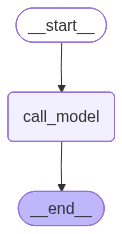

In [22]:
graph

In [23]:
config={'configurable':{'thread_id':'chat-1'}}

result=graph.invoke(
    {'messages':[{'role':'user','content':'Hi, my name is susan.'}]},
    config
)
result['messages'][-1].content

Current token count ->  10
Hi, my name is susan.


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


"Hello Susan! It's nice to meet you. How can I assist you today? Whether it's helping with information search, having a conversation, or anything else you need assistance with, feel free to let me know!"

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [24]:
result=graph.invoke(
    {'messages':[{'role':'user','content':'I am learning langgraph'}]},
    config
)
result['messages'][-1].content

Current token count ->  76
Hi, my name is susan.
Hello Susan! It's nice to meet you. How can I assist you today? Whether it's helping with information search, having a conversation, or anything else you need assistance with, feel free to let me know!
I am learning langgraph


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


"Great to hear that you're learning about LangGraph! LangGraph is a natural language understanding (NLU) model developed by Alibaba Cloud. It's designed to help computers understand and process human language more effectively.\n\nHere are some key aspects of LangGraph:\n\n1. **Natural Language Understanding**: LangGraph can analyze text and extract meaning, intent, entities, and sentiment from it.\n2. **Intent Detection**: Helps in identifying the purpose or goal behind a user’s input.\n3. **Entity Recognition**: Recognizes and extracts important information like names, locations, numbers, etc., from the text.\n4. **Sentiment Analysis**: Determines whether the text is positive, negative, neutral, or something else.\n\nIf you need more detailed explanations or have specific questions about how LangGraph works or how to use it in your projects, feel free to ask!"

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [25]:
result=graph.invoke(
    {'messages':[{'role':'user','content':'can you explain short term memory?'}]},
    config
)
result['messages'][-1].content

Current token count ->  13
can you explain short term memory?


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


'Certainly! Short-term memory (STM) is a fundamental concept in psychology and cognitive science that refers to the temporary storage of information for brief periods. Here’s an overview of what short-term memory involves:\n\n### Key Characteristics:\n1. **Capacity**: The capacity of STM varies widely among individuals, but typically holds around 7 ± 2 pieces of information at any given time (a concept known as "Miller\'s Law" or the "Magazine model"). This amount can be adjusted by different mental processes like chunking.\n\n2. **Duration**: STM has a relatively short duration compared to long-term memory, usually lasting just seconds to about 1 minute. Information in this stage of memory is more labile and less stable than in long-term memory.\n\n3. **Processing Capacity**: Unlike sensory input which lasts only until processed or lost, STM information can be manipulated (for example by rehearsing it) or stored temporarily for further processing.\n\n### Structure:\nSTM can be divided

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [26]:
result=graph.invoke(
    {'messages':[{'role':'user','content':'what is my name?'}]},
    config
)
result['messages'][-1].content

Current token count ->  8
what is my name?


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


"I'm sorry, but I don't have information about who you are or your identity. My purpose is to assist with any queries you might have after knowing your name and context. Could you please provide more details so I can better understand and assist you?"

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
